In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
target_columns = [
    "clover_target",
    "dead_target",
    "green_target",
    "gdm_target",
    "total_target",
]

In [3]:
train_df = pd.read_csv("../../output/exp002/preprocessed_train.csv")
oofs_df = pd.read_csv("../../output/exp002/oofs.csv")

print(train_df[target_columns].shape)
print(oofs_df[target_columns].shape)

# モデルの予測値を表示
print(oofs_df.head())

(357, 5)
(357, 5)
   clover_target  dead_target  green_target  gdm_target  total_target
0       0.172044    41.272682     24.262119   25.164221     65.706863
1       0.467683     3.131485     14.358220   17.127579     17.957388
2       5.247471     0.294048      0.217546    5.537156      5.759065
3       0.766254    36.420204     23.316988   22.177158     60.503460
4       3.002714    11.125539      9.691590   13.302144     23.819843


In [4]:
train_df[target_columns].describe()

,clover_target,dead_target,green_target,gdm_target,total_target
count,357.000000,357.000000,357.000000,357.000000,357.000000
mean,6.649692,12.044548,26.624722,33.274414,45.318097
std,12.117761,12.402007,25.401232,24.935822,27.984015
min,0.000000,0.000000,0.000000,1.040000,1.040000
25%,0.000000,3.200000,8.800000,16.026100,25.271500
50%,1.423500,7.980900,20.800000,27.108200,40.300000
75%,7.242900,17.637800,35.083400,43.675700,57.880000
max,71.786500,83.840700,157.983600,157.983600,185.700000


In [5]:
oofs_df.describe()

,clover_target,dead_target,green_target,gdm_target,total_target
count,357.000000,357.000000,357.000000,357.000000,357.000000
mean,5.747708,11.120954,25.649359,31.561062,42.518021
std,10.750012,9.200872,22.560134,21.743490,23.295449
min,0.000000,0.000000,0.000000,3.498067,2.555385
25%,0.119459,3.910202,9.425077,15.452803,25.534435
50%,1.564791,8.659568,20.171202,25.708445,37.382893
75%,5.487502,16.165384,33.557224,41.962017,55.197163
max,72.371674,47.284805,127.939896,127.298691,136.616440


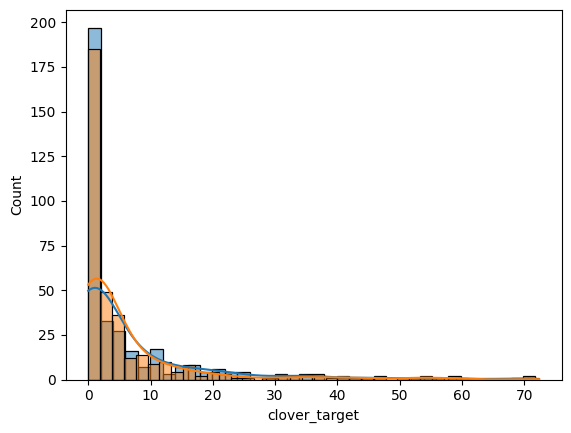

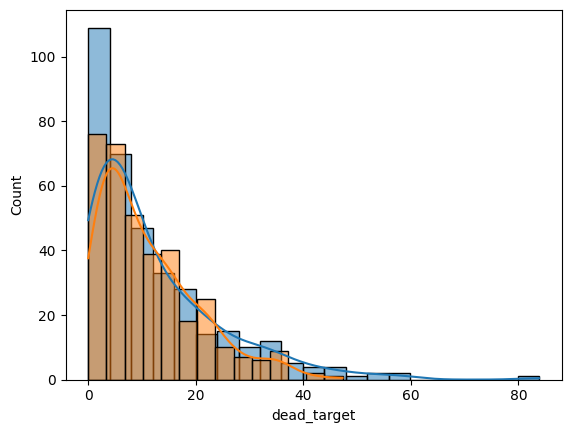

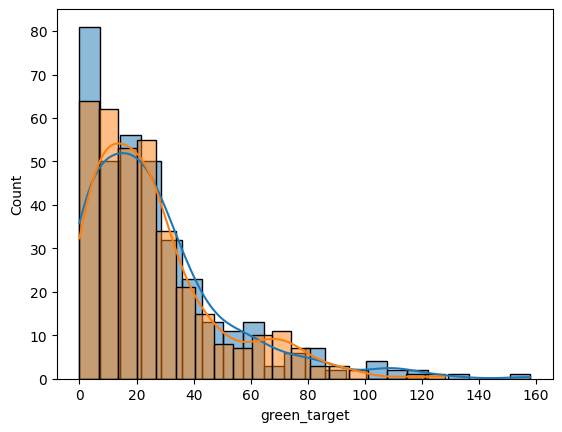

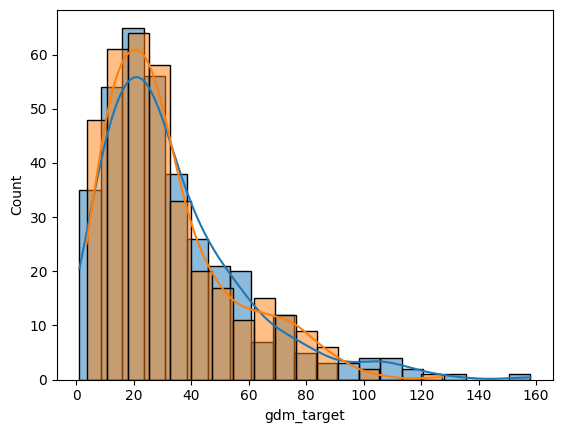

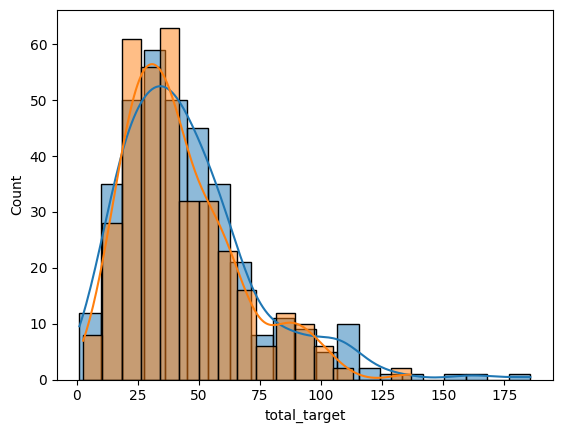

In [6]:
for col in target_columns:
    sns.histplot(data=train_df, x=col, kde=True)
    sns.histplot(data=oofs_df, x=col, kde=True)
    plt.show()

<Axes: xlabel='total_target', ylabel='Count'>

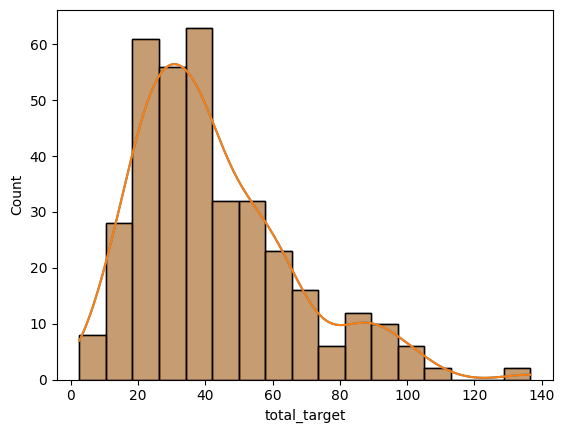

In [7]:
sns.histplot(oofs_df["total_target"], kde=True)
sns.histplot(
    oofs_df[["clover_target", "dead_target", "green_target"]].sum(axis=1), kde=True
)

<Axes: ylabel='Count'>

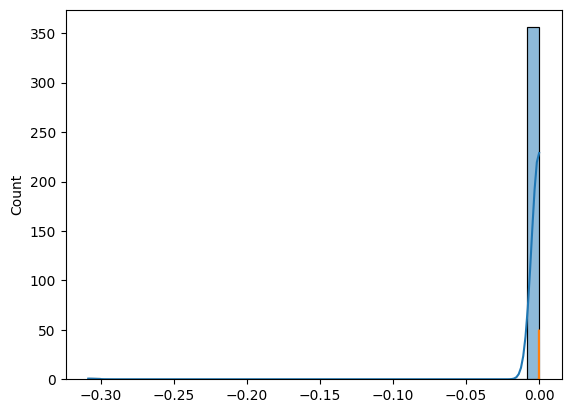

In [8]:
sns.histplot(
    train_df["total_target"]
    - train_df[["clover_target", "dead_target", "green_target"]].sum(axis=1),
    kde=True,
)
sns.histplot(
    oofs_df["total_target"]
    - oofs_df[["clover_target", "dead_target", "green_target"]].sum(axis=1),
    kde=True,
)

In [9]:
(
    train_df["total_target"]
    - train_df[["clover_target", "dead_target", "green_target"]].sum(axis=1)
).value_counts()

 0.000000e+00    254
 7.105427e-15     13
-1.000000e-04     12
-7.105427e-15     10
 1.421085e-14     10
 1.000000e-04     10
 3.552714e-15      7
 1.000000e-04      7
-1.000000e-04      7
-1.421085e-14      6
-1.000000e-04      5
 1.000000e-04      4
-3.552714e-15      3
 1.000000e-04      2
-1.776357e-15      2
 2.842171e-14      1
-3.088000e-01      1
-8.881784e-16      1
-1.000000e-04      1
 1.776357e-15      1
Name: count, dtype: int64

In [11]:
import json

with open("../../output/exp002/results.json", "r") as f:
    results = json.load(f)
results

{'fold_scores': [0.7694759964942932,
  0.7747420191764831,
  0.6953666388988495,
  0.7151999354362488,
  0.6646633386611939],
 'mean_score': 0.7238895857334137,
 'std_score': 0.042569725612964564}

#　所感
- foldごとの精度ばらつきが大きい。なぜ？
- SpicesをGroupKFoldにしてしまうと精度が上がらない
  - StratifiedKFoldにすると安定して向上
  - つまり、種別の汎化性は重要そう
- 画像サイズはそこまで重要じゃないかも？？
  - GroupKFoldで実験してしまっていたので再検討が必要
- `Dry_Total_g = Dry_Clover_g + Dry_Dead_g + Dry_Green_g`となるはずが、誤差大きい。差分のほうがいいかも？
  - モデルは`Dry_Clover_g, Dry_Dead_g, Dry_Green_g, GDM_g`の4つだけ予測するでも良さそう。`Dry_Total_g`は合計でLossを出す。
- total_targetの予測結果がサチっている。分布変換必要かも。
- 負の値はclippingしたほうがよい。
- 全体の雰囲気をみたいのでcnnよりtransformer系のほうが良いかも？
- 高速化・TTA・アンサンブル必須。
- 0gでラベルミスがあるとのことなので気をつけたほうがよい
- ドメインシフトがありそう。気をつけたほうがよい。
- Pre_GSHH_NDVI・Height_Ave_cmもAuxLossで使う必要がある。